<a href="https://colab.research.google.com/github/rekhashida/ecommerce-sales-analysis/blob/main/Ecommerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 E-commerce Sales Analysis — Superstore Dataset

## Objective
Analyze sales, profit, and customer behavior data to generate
actionable business insights for a retail superstore.

## Business Questions
1. Which product categories and sub-categories are most profitable?
2. Which regions and states drive the most sales?
3. What is the monthly sales trend — any seasonality?
4. Which customer segment is most valuable?
5. Which products have high sales but low/negative profit?
6. What is the average discount impact on profit?


In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (4578, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Check data types and nulls
print(df.info())
print("\nNull values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time columns
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')

print("\nDate range:")
print("From:", df['Order Date'].min())
print("To:", df['Order Date'].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4578 entries, 0 to 4577
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4578 non-null   int64  
 1   Order ID       4578 non-null   object 
 2   Order Date     4578 non-null   object 
 3   Ship Date      4578 non-null   object 
 4   Ship Mode      4578 non-null   object 
 5   Customer ID    4578 non-null   object 
 6   Customer Name  4578 non-null   object 
 7   Segment        4578 non-null   object 
 8   Country        4578 non-null   object 
 9   City           4578 non-null   object 
 10  State          4578 non-null   object 
 11  Postal Code    4578 non-null   int64  
 12  Region         4578 non-null   object 
 13  Product ID     4578 non-null   object 
 14  Category       4578 non-null   object 
 15  Sub-Category   4578 non-null   object 
 16  Product Name   4578 non-null   object 
 17  Sales          4578 non-null   float64
 18  Quantity

## 🔍 Exploratory Analysis

### Question 1 — Which category performs best?
Analyzing total sales, profit, and profit margin percentage
across 3 product categories to identify the most valuable one.

> **Finding:** Technology leads with $836K sales and 17.4% margin.
> Furniture generates high sales ($742K) but razor-thin 2.49% margin
> — a major red flag for the business.

In [5]:
# Q1 - Which category performs best?
category = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
category['Profit Margin %'] = ((category['Profit'] / category['Sales']) * 100).round(2)
category = category.sort_values('Sales', ascending=False)
print(category)

                     Sales    Profit  Profit Margin %
Category                                             
Technology       406939.46  58012.37            14.26
Furniture        330574.69   7910.07             2.39
Office Supplies  326531.90  54078.27            16.56


### Question 2 — Which region drives most sales?
Comparing sales and profit across West, East, Central and
South regions to identify strongest and weakest performers.

> **Finding:** West leads in both sales ($725K) and profit ($108K).
> Central region is most inefficient — $501K sales but only
> $39K profit, suggesting heavy discounting or wrong product mix.

In [6]:
# Q2 - Which region drives most sales?
region = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
region = region.sort_values('Sales', ascending=False)
print(region)

             Sales    Profit
Region                      
West     329684.47  43135.10
East     306833.58  40471.40
Central  230987.62  15016.86
South    196540.36  21377.35


### Question 3 — What is the monthly sales trend?
Analyzing sales patterns month by month across 4 years
to identify seasonality and peak business periods.

> **Finding:** Sales consistently spike in November-December
> every year (holiday season) and dip in January-February.
> September also shows a notable spike annually.

In [7]:
# Q3 - Monthly sales trend
monthly = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
print(monthly.head(12))

    Order Year  Order Month       Sales
0         2014            1   6221.2980
1         2014            2   1362.5060
2         2014            3  33887.9310
3         2014            4  13391.8550
4         2014            5  11089.2350
5         2014            6  24693.5356
6         2014            7  21470.4440
7         2014            8  15682.8285
8         2014            9  46543.1318
9         2014           10  15259.9610
10        2014           11  41441.7980
11        2014           12  35121.7485


### Question 4 — Which customer segment is most valuable?
Comparing Consumer, Corporate, and Home Office segments
by sales volume and profit margin to find best segment.

> **Finding:** Consumer has highest sales ($1.16M) but lowest
> margin (11.55%). Home Office has best margin (14.03%) despite
> smallest sales — quality over quantity.

In [8]:
# Q4 - Which segment is most valuable?
segment = df.groupby('Segment')[['Sales', 'Profit']].sum().round(2)
segment['Profit Margin %'] = ((segment['Profit'] / segment['Sales']) * 100).round(2)
print(segment)

                 Sales    Profit  Profit Margin %
Segment                                          
Consumer     539090.06  64042.20            11.88
Corporate    306219.20  31596.31            10.32
Home Office  218736.78  24362.20            11.14


### Question 5 — Which products are loss makers?
Identifying sub-categories where total profit is negative
— products that are actively losing money for the business.

> **Finding:** 12 sub-categories are losing money. Binders
> (-$38K), Tables (-$32K), and Machines (-$30K) are the worst.
> These need immediate pricing or discount review.

In [9]:
# Q5 - Products with negative profit (loss makers)
loss = df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().round(2)
loss = loss.sort_values()
print("Loss making sub-categories:")
print(loss)

Loss making sub-categories:
Sub-Category
Machines      -18753.15
Binders       -16271.99
Tables        -15352.22
Bookcases      -5393.93
Chairs         -4047.98
Phones         -3454.85
Appliances     -3267.91
Storage        -3207.59
Furnishings    -3113.92
Supplies       -1847.48
Accessories     -379.44
Fasteners         -7.43
Name: Profit, dtype: float64


### Question 6 — What is the discount impact on profit?
Measuring correlation between discount percentage and profit
to understand if discounting strategy is helping or hurting.

> **Finding:** Correlation = -0.22. At 0% discount average profit
> is $66.90. At 45% discount average profit is -$226.
> Discounts above 30% almost always cause losses.

In [10]:
# Q6 - Does discount hurt profit?
discount = df.groupby('Discount')[['Sales', 'Profit']].mean().round(2)
print(discount)
correlation = df['Discount'].corr(df['Profit'])
print(f"\nCorrelation between Discount and Profit: {correlation:.2f}")

            Sales  Profit
Discount                 
0.00       223.97   64.54
0.10       592.36  108.67
0.15       476.96   25.66
0.20       209.92   23.06
0.30       455.57  -45.03
0.32       523.97  -90.69
0.40       547.22 -108.52
0.45       457.50 -194.74
0.50      1569.17 -468.46
0.60        55.52  -50.09
0.70       106.39 -100.61
0.80        43.13  -78.30

Correlation between Discount and Profit: -0.24


## ✅ Summary — Exploratory Analysis Complete

Answered 6 business questions using groupby, aggregation,
and correlation analysis:

| Question | Method | Key Finding |
|---|---|---|
| Category Performance | groupby + margin calc | Technology best (17.4% margin) |
| Regional Performance | groupby sum | West most profitable |
| Monthly Trend | groupby year+month | Strong Q4 seasonality |
| Segment Analysis | groupby + margin | Home Office best margin |
| Loss Makers | filter + groupby | Binders losing $38K |
| Discount Impact | corr() | -0.22 correlation |

### Overall Business Health
- Total Sales: $2.3M across 4 years
- Total Profit: $286K overall
- Overall Profit Margin: ~12.4%
- Biggest Problem: Heavy discounting destroying margins

---
*Next →  Visualizations*

## 📊 Visualizations

### Chart 1 — Category Performance Analysis
Analyzing which product category generates the most sales
and which is most profitable by margin percentage.

> **Insight:** Technology leads both sales ($836K) and profit margin
> (17.4%). Furniture generates $742K in sales but has a dangerously
> low margin of just 2.49% — meaning high revenue but very little
> actual profit. Office Supplies has a healthy 17% margin despite
> lower sales volume.

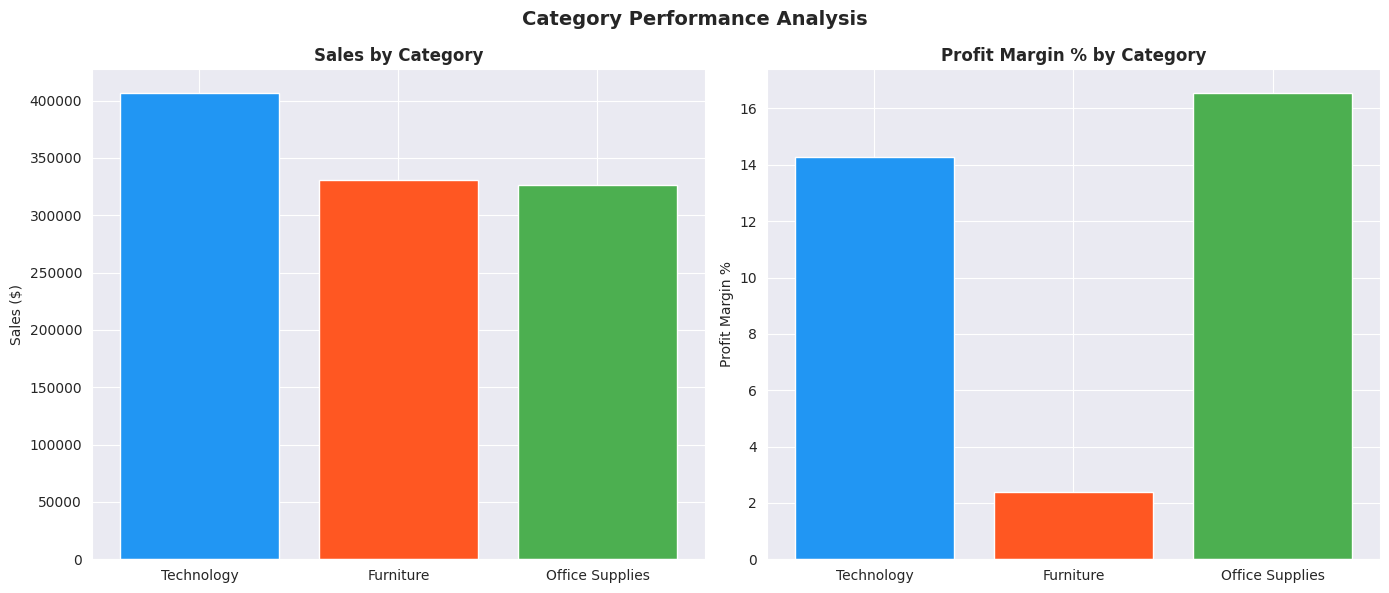

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sales by category
ax1.bar(category.index, category['Sales'], color=['#2196F3', '#FF5722', '#4CAF50'])
ax1.set_title('Sales by Category', fontweight='bold')
ax1.set_ylabel('Sales ($)')

# Profit margin by category
ax2.bar(category.index, category['Profit Margin %'], color=['#2196F3', '#FF5722', '#4CAF50'])
ax2.set_title('Profit Margin % by Category', fontweight='bold')
ax2.set_ylabel('Profit Margin %')

plt.suptitle('Category Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Regional Performance
Comparing sales and profit across 4 regions to identify
which regions are most efficient and which need attention.

> **Insight:** West region leads in both sales ($725K) and profit
> ($108K). The Central region is most concerning — $501K in sales
> but only $39K profit, the lowest profit-to-sales ratio of all
> regions. This suggests Central region may be over-discounting
> or selling low-margin products.

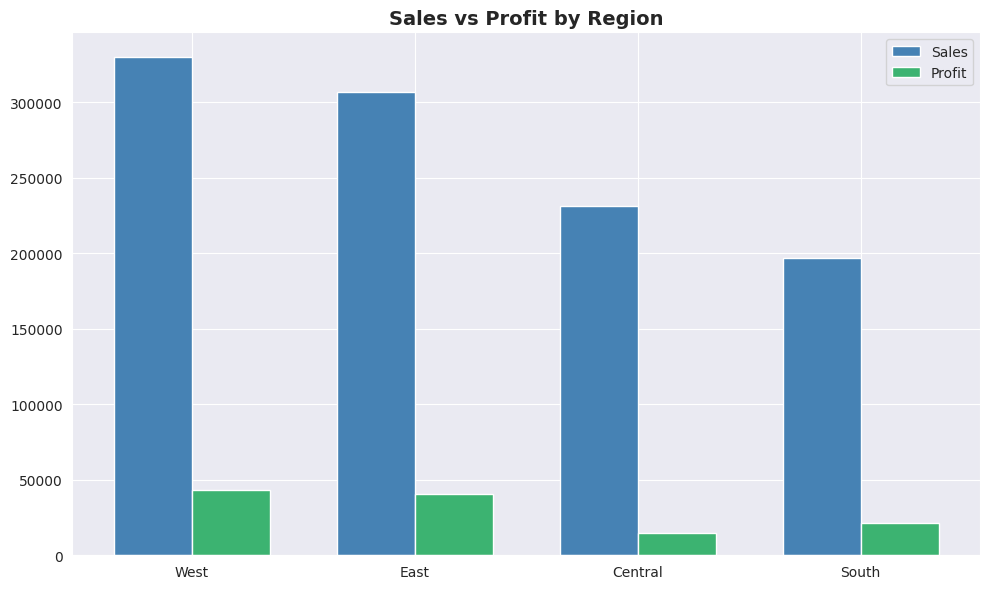

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(region.index))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], region['Sales'],
               width, label='Sales', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], region['Profit'],
               width, label='Profit', color='mediumseagreen')

ax.set_title('Sales vs Profit by Region', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(region.index)
ax.legend()
plt.tight_layout()
plt.savefig('region_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Monthly Sales Trend (2014–2017)
Analyzing seasonality patterns across 4 years to identify
peak and low sales months for business planning.

> **Insight:** A clear seasonality pattern emerges across all 4 years
> — sales consistently dip in January-February and spike in
> November-December (holiday season). September also shows a
> notable spike every year. This suggests the business should
> stock up inventory and run promotions heading into Q4.

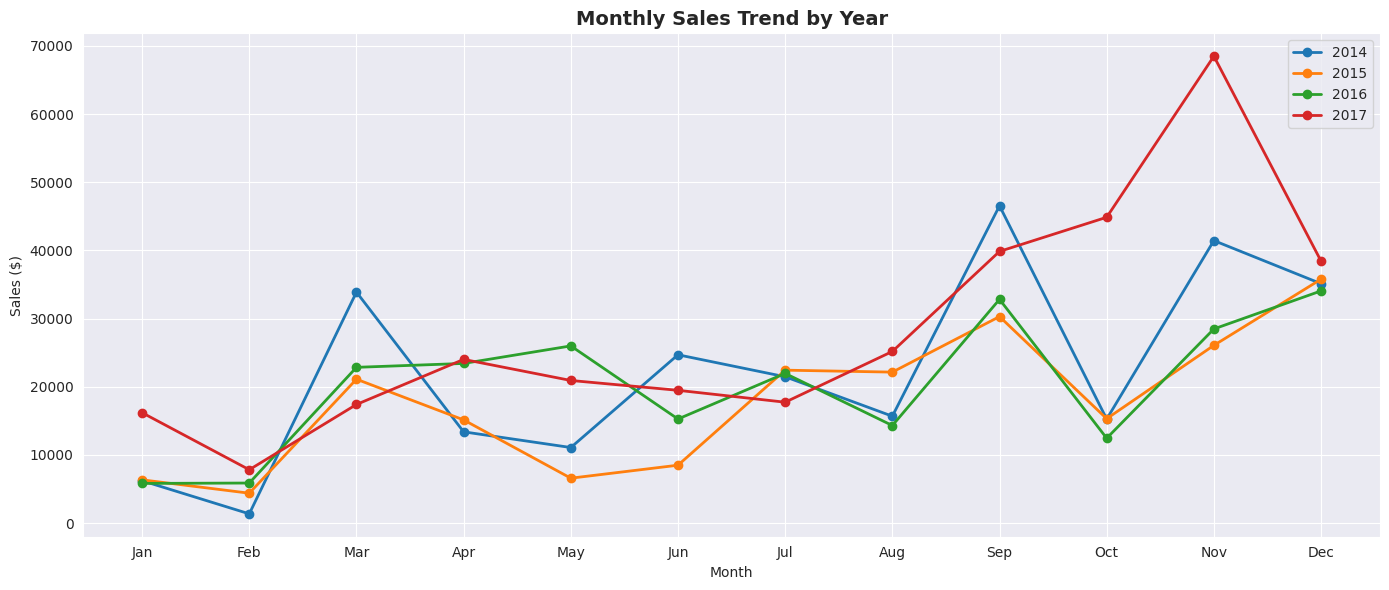

In [14]:
monthly_total = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
for year in monthly_total['Order Year'].unique():
    data = monthly_total[monthly_total['Order Year'] == year]
    plt.plot(data['Order Month'], data['Sales'],
             marker='o', label=str(year), linewidth=2)

plt.title('Monthly Sales Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4 — Loss Making Sub-Categories
Identifying which sub-categories are bleeding profit despite
generating sales — these are the business's biggest problem areas.

> **Insight:** Binders (-$38K), Tables (-$32K), and Machines (-$30K)
> are the top 3 loss makers. These sub-categories are likely being
> sold at heavy discounts that wipe out all profit. A business
> decision to either reprice these products or discontinue heavy
> discounting could significantly improve overall profitability.

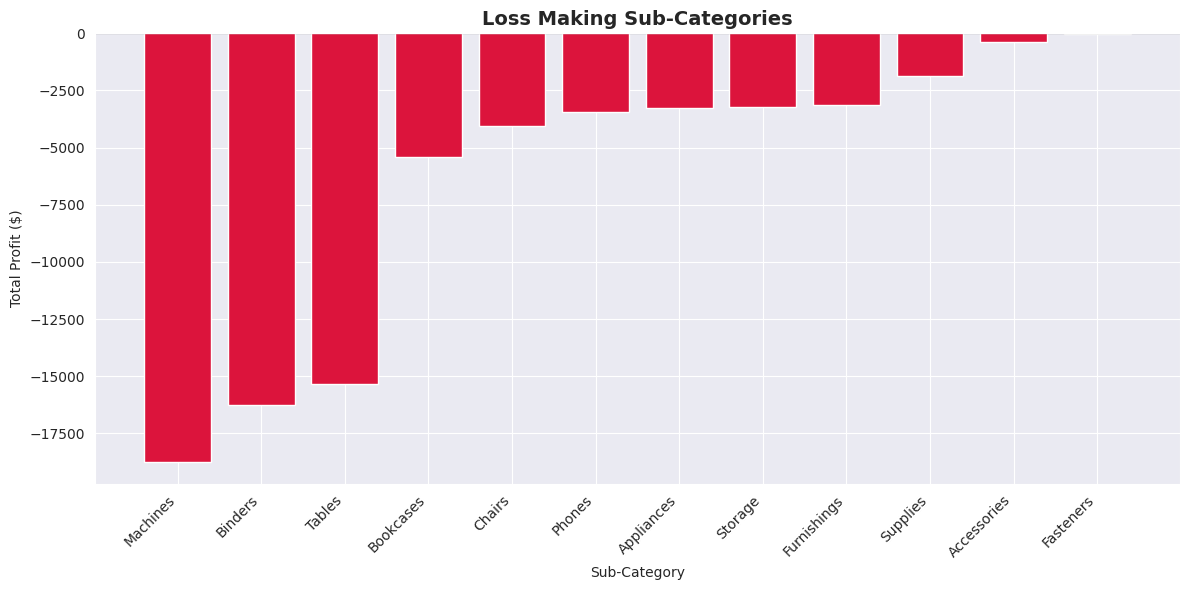

In [15]:
plt.figure(figsize=(12, 6))
colors = ['crimson' if x < 0 else 'mediumseagreen' for x in loss.values]
plt.bar(loss.index, loss.values, color=colors, edgecolor='white')
plt.title('Loss Making Sub-Categories', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('loss_makers.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5 — Discount Impact on Profit
Investigating whether discounting strategy is helping or
hurting the business's bottom line.

> **Insight:** The scatter plot clearly shows that as discount
> increases, profit drops — confirmed by correlation of -0.22.
> At 0% discount, average profit is $66.90. At 45% discount,
> average profit crashes to -$226. The red line (zero profit)
> shows that discounts above 30% almost always result in losses.
> This is a critical finding — the business is losing money
> on heavily discounted orders.

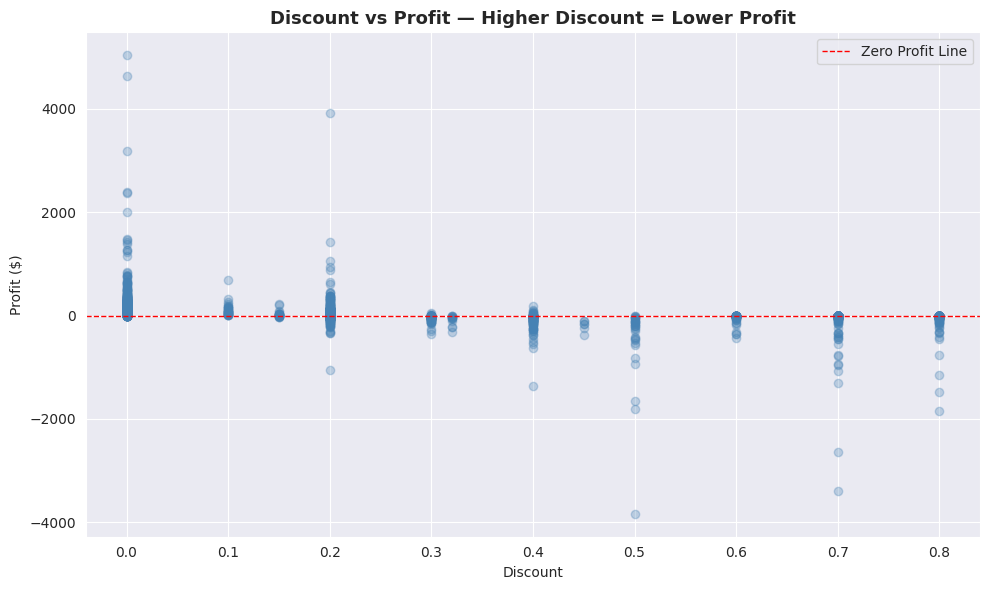

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue')
plt.axhline(y=0, color='red', linewidth=1, linestyle='--', label='Zero Profit Line')
plt.title('Discount vs Profit — Higher Discount = Lower Profit',
          fontsize=13, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6 — Customer Segment Profit Margin
Understanding which customer segment delivers the most
value in terms of profit margin, not just raw sales volume.

> **Insight:** Despite Consumer segment having the highest total
> sales ($1.16M), Home Office delivers the best profit margin
> at 14.03%. Corporate sits in the middle at 13.03%. This suggests
> the business should focus marketing efforts on Home Office
> customers for better profitability per dollar of sales.

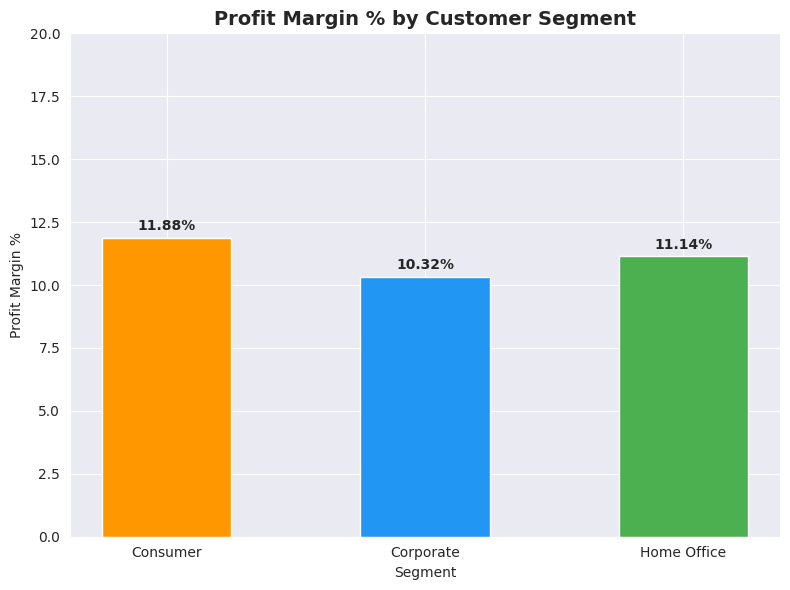

In [17]:
plt.figure(figsize=(8, 6))
plt.bar(segment.index, segment['Profit Margin %'],
        color=['#FF9800', '#2196F3', '#4CAF50'], edgecolor='white', width=0.5)
plt.title('Profit Margin % by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Profit Margin %')
plt.ylim(0, 20)
for i, v in enumerate(segment['Profit Margin %']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('segment_margin.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Summary — Visualizations Complete

6 charts created covering the full business story:

| Chart | Type | Key Finding |
|---|---|---|
| Category Performance | Double Bar | Technology best margin (17.4%) |
| Regional Performance | Grouped Bar | Central region least efficient |
| Monthly Sales Trend | Line Chart | Clear Q4 seasonality every year |
| Loss Making Products | Bar Chart | Binders losing most (-$38K) |
| Discount vs Profit | Scatter | Discounts >30% always cause losses |
| Segment Margin | Bar Chart | Home Office best margin (14.03%) |

---
*Next → SQL Queries*